# Winter wheat phenology — TorchCrop against CyBench

**What this notebook does.** It derives the simulated stage dates from the
10 km TorchCrop run, averages them to national dates, and compares them with
the CyBench crop calendar. RMSE, MAE, Bias and Pearson r are reported per stage
and per country.

## What each side actually contains

Read this before the results — two of the three stage pairings are proxies, and
the fourth requested stage does not exist on either side.

| Stage | TorchCrop | CyBench | Comparable? |
|---|---|---|---|
| Sowing | **constant input**, DOY 270 for every cell | `sos` | weakly — see below |
| Flowering | **not in the run** | **not in the calendar** | no |
| Maturity | first day at `DVS ≥ 2` | `eos` | yes, best pairing |
| Harvest | not modelled; = maturity + `HARVEST_LAG_DAYS` (0) | `eos` | as maturity |

* **Sowing is not a prediction.** The SIMPLACE export carries no sowing
  calendar, so `torchcrop_run.py` sows every cell from Crete to Lapland on
  DOY 270. Its only degree of freedom is one continental offset.
* **CyBench `sos` is not a sowing date, and it changes meaning with climate.**
  It is ~DOY 330–360 in Spain, Greece and Portugal (autumn sowing) but ~DOY
  40–75 in Germany, Poland and the Baltics (post-winter green-up). The northern
  residuals are a convention difference, not a model error; §7 separates the
  two regimes so this is visible rather than buried in a mean.
* **Flowering is absent from both.** `run_batch` discards the DVS trajectory
  once it has dated the fertilizer schedule, so no anthesis date reaches the
  Parquet, and the CyBench calendar carries only a season start and end. It is
  therefore not evaluated here. Emitting the `DVS ≥ 1` crossing in
  `submit/torchcrop_run.py` and re-running the shards would supply the
  simulated side; the reference side would still need another source.
* **Harvest is maturity.** LINTUL-5 stops the crop at `DVS = 2` and models no
  drydown. The row is kept because the assumption should be visible, not
  because it adds information; raise `config.HARVEST_LAG_DAYS` to test a lag.

## Two conventions

1. **Error is `simulated − observed`**, so a positive bias means the model is
   **late**.
2. **Every date statistic is circular.** A day-of-year lives on a circle:
   means go through `doy.circular_mean_doy`, errors through
   `doy.doy_difference`, and correlations are computed on both sides unwrapped
   about the observed circular mean. Without that, Spain's regional `sos` of
   DOY 363 and DOY 0.7 average to July.

All reusable code is in [`utils/`](utils/); this notebook is the workflow only.

## 0. Setup

In [1]:
import logging
import sys
from pathlib import Path

# The notebooks live beside utils/, so they import it without installation.
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd

from utils import aggregate, config, cybench, doy, metrics, plots, regions, torchcrop
from utils.style import use_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = use_style("light")
config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"TorchCrop run : {config.TORCHCROP_RUN_DIR}")
print(f"CyBench root  : {config.CYBENCH_ROOT}")
print(f"Outputs       : {config.OUTPUT_DIR}")

TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/torchcrop/winter_wheat_2000_2024
CyBench root  : /data01/FDS/muduchuru/Data/Agri/cybench
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs


## 1. Scope — which countries are evaluable

In [2]:
COUNTRIES = config.available_countries()

scope = pd.DataFrame({
    "code": list(config.TARGET_COUNTRIES),
    "name": [config.COUNTRY_NAMES.get(c, c) for c in config.TARGET_COUNTRIES],
    "eu27": [c in config.EU27 for c in config.TARGET_COUNTRIES],
    "schengen_non_eu": [c in config.SCHENGEN_NON_EU for c in config.TARGET_COUNTRIES],
    "in_cybench": [c in COUNTRIES for c in config.TARGET_COUNTRIES],
}).set_index("code")

print(f"{len(COUNTRIES)} of {len(config.TARGET_COUNTRIES)} target countries are evaluable")
print("missing:", ", ".join(scope.index[~scope["in_cybench"]]))
scope

23 of 31 target countries are evaluable
missing: CH, CY, IS, LI, LU, MT, NO, SI


,name,eu27,schengen_non_eu,in_cybench
code,,,,
AT,Austria,True,False,True
BE,Belgium,True,False,True
BG,Bulgaria,True,False,True
CH,Switzerland,False,True,False
CY,Cyprus,True,False,False
CZ,Czechia,True,False,True
DE,Germany,True,False,True
DK,Denmark,True,False,True
EE,Estonia,True,False,True


## 2. Load the simulation and derive the stage dates

`days_to_maturity` counts from the sowing latch, so maturity is
`sowing_doy + days_to_maturity` wrapped back into the year: a crop sown on
DOY 270 and maturing 272 days later matures on DOY 177 of the following
calendar year, which is the harvest year the row is labelled with.

In [3]:
sim = torchcrop.load_simulation(columns=[
    "SimplaceID", "year", "lon", "lat", "days_to_maturity", "final_dvs", "yield_t_ha",
])

print("stages derived:", ", ".join(torchcrop.PHENOLOGY_COLUMNS))
for stage in config.STAGES:
    print(f"  {stage.label:9s} <- {stage.sim_col:14s} vs CyBench '{stage.obs_col}'")

sim[list(torchcrop.PHENOLOGY_COLUMNS)].describe().T

INFO utils.torchcrop: read torchcrop_europe.parquet: 1717125 rows, 7 columns


WARNING utils.torchcrop: 70 of 1717125 rows (0.00%) never reached maturity; their dates are NaN


stages derived: sowing_doy, maturity_doy, harvest_doy, season_length_days
  Sowing    <- sowing_doy     vs CyBench 'sos'
  Maturity  <- maturity_doy   vs CyBench 'eos'
  Harvest   <- harvest_doy    vs CyBench 'eos'


,count,mean,std,min,25%,50%,75%,max
sowing_doy,1717125.0,270.000000,0.000000,270.0,270.0,270.0,270.0,270.0
maturity_doy,1717055.0,168.342887,44.475960,1.0,148.0,177.0,200.0,365.0
harvest_doy,1717055.0,168.342887,44.475960,1.0,148.0,177.0,200.0,365.0
season_length_days,1717055.0,263.230861,44.449448,82.0,243.0,272.0,295.0,486.0


## 3. Assign each 10 km cell to a country

In [4]:
cells = torchcrop.simulation_cells(sim)
cells = regions.assign_cells_to_countries(
    cells, COUNTRIES, cache=regions.default_cache_path(len(COUNTRIES))
)

sim = sim.merge(cells[["SimplaceID", "country", "snapped"]], on="SimplaceID", how="left")
scoped = sim[sim["country"].notna()].copy()

print(f"{cells['country'].notna().sum():,} of {len(cells):,} cells inside the "
      f"CyBench footprint ({cells['snapped'].sum():,} matched by the {config.SNAP_KM} km snap)")
print(f"{len(scoped):,} of {len(sim):,} simulated cell-seasons kept")

cells_per_country = (
    cells.dropna(subset=["country"]).groupby("country").size().rename("cells").to_frame()
)
cells_per_country["share_%"] = (
    100 * cells_per_country["cells"] / cells_per_country["cells"].sum()
).round(1)
cells_per_country.T

INFO utils.torchcrop: 68685 unique cells


INFO utils.regions: cell-to-country map read from /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/cache/cell_country_n23_snap5km.parquet


30,406 of 68,685 cells inside the CyBench footprint (779 matched by the 5.0 km snap)
760,150 of 1,717,125 simulated cell-seasons kept


country,AT,BE,BG,CZ,DE,DK,EE,EL,ES,FI,...,IE,IT,LT,LV,NL,PL,PT,RO,SE,SK
cells,398.0,378.0,978.0,826.0,4297.0,729.0,471.0,602.0,3258.0,120.0,...,279.0,1710.0,861.0,757.0,424.0,3880.0,376.0,2025.0,778.0,465.0
share_%,1.3,1.2,3.2,2.7,14.1,2.4,1.5,2.0,10.7,0.4,...,0.9,5.6,2.8,2.5,1.4,12.8,1.2,6.7,2.6,1.5


## 4. Aggregate the simulation to national dates

Every stage column is flagged circular, so the national date is a circular
mean. `season_length_days` is a **duration**, not a date, so it stays linear.

In [5]:
STAGE_COLS = {stage.sim_col: True for stage in config.STAGES}
STAGE_COLS["season_length_days"] = False

sim_country = aggregate.aggregate_simulated(scoped, STAGE_COLS)
sim_country.head()

INFO utils.aggregate: simulated: 575 country-groups, 120-5300 cells each


,country,year,sowing_doy,sim_method,n_cells,maturity_doy,harvest_doy,season_length_days
0,AT,2000,270.0,unweighted,398,180.342229,180.342229,275.484925
1,AT,2001,270.0,unweighted,398,179.343834,179.343834,274.437186
2,AT,2002,270.0,unweighted,398,175.639787,175.639787,270.713568
3,AT,2003,270.0,unweighted,398,181.513996,181.513996,276.582915
4,AT,2004,270.0,unweighted,398,197.705405,197.705405,292.791457


## 5. Load and aggregate the CyBench crop calendar

The calendar is **static** — one `sos`/`eos` per administrative unit, with no
year dimension. Every simulated season is therefore compared against the same
reference date, which means interannual scatter in the simulation can only be
penalised, never rewarded. Regions are weighted by `crop_area` from the CyBench
crop mask, so a 200 ha alpine district does not outvote a 200 000 ha plain.

In [6]:
calendar = cybench.load_calendar(COUNTRIES)
crop_mask = cybench.load_crop_mask(COUNTRIES)
obs_country = aggregate.aggregate_observed_calendar(calendar, crop_mask)

obs_country["sos_date"] = obs_country["sos"].map(lambda d: doy.doy_to_month_day(d))
obs_country["eos_date"] = obs_country["eos"].map(lambda d: doy.doy_to_month_day(d))
obs_country.set_index("country").round(1)

INFO utils.cybench: observed calendars: 938 regions, 23 countries


INFO utils.cybench: crop masks: 946 regions


INFO utils.aggregate: observed calendars: 23 countries


,sos,obs_method,n_regions,eos,sos_date,eos_date
country,,,,,,
AT,52.2,weighted,9,217.7,21 Feb,5 Aug
BE,41.8,weighted,11,214.7,10 Feb,2 Aug
BG,38.7,weighted,6,207.7,7 Feb,26 Jul
CZ,52.4,weighted,14,220.0,21 Feb,7 Aug
DE,46.7,weighted,400,219.4,15 Feb,7 Aug
DK,53.8,weighted,11,218.6,22 Feb,6 Aug
EE,70.1,weighted,5,223.2,11 Mar,11 Aug
EL,351.2,weighted,47,190.5,17 Dec,9 Jul
ES,345.2,weighted,54,184.1,11 Dec,3 Jul


### The two `sos` conventions

The split is the reason a single "sowing" metric would be meaningless. A
country whose observed `sos` falls in the autumn is reporting a sowing date; one
whose `sos` falls after New Year is reporting a green-up.

In [7]:
AUTUMN_SOS_THRESHOLD = 200.0  # DOY; above it, sos is an autumn date

obs_country["sos_regime"] = np.where(
    obs_country["sos"] >= AUTUMN_SOS_THRESHOLD, "autumn sowing", "post-winter green-up"
)
regimes = obs_country.groupby("sos_regime")["country"].apply(list)
for regime, members in regimes.items():
    print(f"{regime:22s} ({len(members):2d}): {', '.join(sorted(members))}")

autumn sowing          ( 4): EL, ES, IT, PT
post-winter green-up   (19): AT, BE, BG, CZ, DE, DK, EE, FI, FR, HR, HU, IE, LT, LV, NL, PL, RO, SE, SK


## 6. Pair the two sides

The join is on `country` alone: the reference has no year, so each simulated
country-year is paired against its country's climatological calendar.

In [8]:
paired = aggregate.pair_observations(sim_country, obs_country, ["country"])

for stage in config.STAGES:
    paired[f"{stage.key}_error"] = doy.doy_difference(
        paired[stage.sim_col], paired[stage.obs_col]
    )

print(f"{len(paired)} country-years across {paired['country'].nunique()} countries")
paired.head()

INFO utils.aggregate: paired 575 rows; 0 simulated-only and 0 observed-only dropped


575 country-years across 23 countries


,country,year,sowing_doy,sim_method,n_cells,maturity_doy,harvest_doy,season_length_days,sos,obs_method,n_regions,eos,sos_date,eos_date,sos_regime,sowing_error,maturity_error,harvest_error
0,AT,2000,270.0,unweighted,398,180.342229,180.342229,275.484925,52.19883,weighted,9,217.657866,21 Feb,5 Aug,post-winter green-up,-147.19883,-37.315637,-37.315637
1,AT,2024,270.0,unweighted,398,153.972045,153.972045,249.052764,52.19883,weighted,9,217.657866,21 Feb,5 Aug,post-winter green-up,-147.19883,-63.685821,-63.685821
2,AT,2023,270.0,unweighted,398,173.680722,173.680722,268.741206,52.19883,weighted,9,217.657866,21 Feb,5 Aug,post-winter green-up,-147.19883,-43.977144,-43.977144
3,AT,2022,270.0,unweighted,398,177.754792,177.754792,272.819095,52.19883,weighted,9,217.657866,21 Feb,5 Aug,post-winter green-up,-147.19883,-39.903074,-39.903074
4,AT,2021,270.0,unweighted,398,187.674208,187.674208,282.743719,52.19883,weighted,9,217.657866,21 Feb,5 Aug,post-winter green-up,-147.19883,-29.983658,-29.983658


## 7. Metrics by stage

Pooled across every country-year. Two correlations are undefined here and come
back as NaN, both for the same reason — a constant has no variance:

* **Sowing**, because the *simulated* date is the DOY 270 latch.
* **Every per-country row** in the next section, because the *observed* date is
  a single climatological value repeated across that country's years.

The pooled maturity `pearson_r` is therefore a **spatial** correlation across
the 23 countries, not an interannual one.

In [9]:
pooled = {}
for stage in config.STAGES:
    pooled[stage.label] = metrics.phenology_metrics(
        paired[stage.obs_col], paired[stage.sim_col]
    )

pooled_table = pd.DataFrame(pooled).T[list(metrics.PHENOLOGY_METRIC_ORDER)]
pooled_table["observed date"] = pooled_table["obs_mean"].map(doy.doy_to_month_day)
pooled_table["simulated date"] = pooled_table["sim_mean"].map(doy.doy_to_month_day)

pooled_table.round(2)

,n,obs_mean,sim_mean,bias,mae,rmse,pearson_r,observed date,simulated date
Sowing,575.0,40.91,270.00,-134.43,134.43,137.52,NaN,9 Feb,27 Sep
Maturity,575.0,211.00,170.77,-41.82,43.96,50.81,0.89,30 Jul,19 Jun
Harvest,575.0,211.00,170.77,-41.82,43.96,50.81,0.89,30 Jul,19 Jun


In [10]:
for stage in config.STAGES:
    print(f"--- {stage.label} ---")
    print(stage.caveat)
    print()

--- Sowing ---
Weak pairing. The simulated date is a constant model input (DOY 270), not a prediction, so its only degree of freedom is a single continental offset. CyBench 'sos' is a start-of-season, and it switches convention with climate: ~DOY 330-360 in ES/EL/PT/southern IT (autumn sowing) but ~DOY 40-75 in DE/PL/EE/LV (post-winter green-up). Read the northern residuals as a convention difference, not a model error.

--- Maturity ---
Strongest pairing. Simulated maturity is the first day at DVS >= 2; CyBench 'eos' is the end of season, which for winter wheat falls at harvest (~DOY 205-225). The residual absorbs the maturity-to-harvest interval as well as any model error.

--- Harvest ---
Identical to maturity while HARVEST_LAG_DAYS = 0: LINTUL-5 stops the crop at DVS = 2 and models no drydown, so it predicts no harvest date of its own. Raise the lag to test a drydown assumption; the row is kept so the assumption stays visible.



### Per country and stage

One table per stage, and a wide summary across all three.

In [11]:
stage_metrics = {
    stage.key: metrics.metrics_by_group(
        paired, stage.obs_col, stage.sim_col, metric_fn=metrics.phenology_metrics
    )
    for stage in config.STAGES
}

summary = pd.concat(
    {stage.label: stage_metrics[stage.key][["n", "bias", "mae", "rmse", "pearson_r"]]
     for stage in config.STAGES},
    axis=1,
)
summary.to_csv(config.TABLE_DIR / "phenology_metrics_by_country_stage.csv",
               float_format="%.3f")
summary.round(1)

Sowing                                Maturity                             Harvest                            
             n   bias    mae   rmse pearson_r        n  bias   mae  rmse pearson_r       n  bias   mae  rmse pearson_r
country                                                                                                               
AT          25 -147.2  147.2  147.2       NaN       25 -38.9  38.9  40.1       NaN      25 -38.9  38.9  40.1       NaN
BE          25 -136.8  136.8  136.8       NaN       25 -52.8  52.8  54.1       NaN      25 -52.8  52.8  54.1       NaN
BG          25 -133.7  133.7  133.7       NaN       25 -53.6  53.6  54.5       NaN      25 -53.6  53.6  54.5       NaN
CZ          25 -147.4  147.4  147.4       NaN       25 -29.1  29.1  30.6       NaN      25 -29.1  29.1  30.6       NaN
DE          25 -141.7  141.7  141.7       NaN       25 -40.0  40.0  41.5       NaN      25 -40.0  40.0  41.5       NaN
DK          25 -148.8  148.8  148.8       NaN       25 -27.3  27.3  29.5       NaN      25 -27.3  27.3  29.5       NaN
EE          25 -165.1  165.1  165.1       NaN       25   0.0   7.5   9.6       NaN      25   0.0   7.5   9.6       NaN
EL          25  -81.2   81.2   81.2       NaN       25 -76.5  76.5  77.4       NaN      25 -76.5  76.5  77.4       NaN
ES          25  -75.2   75.2   75.2       NaN       25 -69.3  69.3  69.9       NaN      25 -69.3  69.3  69.9       NaN
FI          25 -158.1  158.1  158.1       NaN       25  18.2  18.3  21.2       NaN      25  18.2  18.3  21.2       NaN
FR          25 -120.4  120.4  120.4       NaN       25 -64.4  64.4  65.2       NaN      25 -64.4  64.4  65.2       NaN
HR          25 -137.2  137.2  137.2       NaN       25 -59.2  59.2  60.3       NaN      25 -59.2  59.2  60.3       NaN
HU          25 -139.2  139.2  139.2       NaN       25 -56.2  56.2  57.0       NaN      25 -56.2  56.2  57.0       NaN
IE          25 -130.6  130.6  130.6       NaN       25 -45.0  45.0  46.2       NaN      25 -45.0  45.0  46.2       NaN
IT          25  -93.1   93.1   93.1       NaN       25 -76.8  76.8  77.5       NaN      25 -76.8  76.8  77.5       NaN
LT          25 -170.7  170.7  170.7       NaN       25 -14.4  14.8  17.0       NaN      25 -14.4  14.8  17.0       NaN
LV          25 -172.0  172.0  172.0       NaN       25  -7.4  10.1  12.0       NaN      25  -7.4  10.1  12.0       NaN
NL          25 -138.9  138.9  138.9       NaN       25 -51.2  51.2  52.8       NaN      25 -51.2  51.2  52.8       NaN
PL          25 -151.1  151.1  151.1       NaN       25 -30.3  30.3  31.7       NaN      25 -30.3  30.3  31.7       NaN
PT          25  -61.4   61.4   61.4       NaN       25 -98.3  98.3  98.6       NaN      25 -98.3  98.3  98.6       NaN
RO          25 -140.6  140.6  140.6       NaN       25 -47.3  47.3  48.1       NaN      25 -47.3  47.3  48.1       NaN
SE          25 -154.3  154.3  154.3       NaN       25  -7.9  10.1  12.1       NaN      25  -7.9  10.1  12.1       NaN
SK          25 -147.2  147.2  147.2       NaN       25 -34.2  34.2  35.4       NaN      25 -34.2  34.2  35.4       NaN
ALL        575 -134.4  134.4  137.5       NaN      575 -41.8  44.0  50.8       0.9     575 -41.8  44.0  50.8       0.9

> **The per-country `pearson_r` column is NaN by construction, not by
> accident.** The CyBench calendar has no year dimension, so within one country
> the observed date is the same value in every paired year — a constant has no
> variance to correlate against. The column is kept rather than hidden so the
> limitation is visible in the table itself.
>
> The **pooled** `pearson_r` in §7 is therefore a *spatial* correlation across
> the 23 countries, not an interannual one: it says the model orders the
> countries' seasons correctly. Nothing here tests whether it tracks a warm
> year against a cold one — that would need a year-resolved reference.

In [12]:
maturity_ranked = metrics.rank_countries(stage_metrics["maturity"], by="rmse")

plots.metric_table(
    maturity_ranked, ("rank", *metrics.PHENOLOGY_METRIC_ORDER), precision=1,
    caption="Maturity (simulated DVS >= 2) against CyBench 'eos', ranked by "
            "RMSE in days. obs_mean/sim_mean are days-of-year; bias, MAE and "
            "RMSE are in days, positive meaning the model is late.",
)

,rank,n,Observed mean,Simulated mean,Bias,MAE,RMSE,Pearson r
Estonia (EE),1.0,25,223.2,223.2,0.0,7.5,9.6,—
Latvia (LV),2.0,25,225.1,217.7,-7.4,10.1,12.0,—
Sweden (SE),3.0,25,219.9,212.0,-7.9,10.1,12.1,—
Lithuania (LT),4.0,25,225.4,211.1,-14.4,14.8,17.0,—
Finland (FI),5.0,25,220.2,238.3,18.2,18.3,21.2,—
Denmark (DK),6.0,25,218.6,191.3,-27.3,27.3,29.5,—
Czechia (CZ),7.0,25,220.0,190.9,-29.1,29.1,30.6,—
Poland (PL),8.0,25,220.7,190.4,-30.3,30.3,31.7,—
Slovakia (SK),9.0,25,218.9,184.6,-34.2,34.2,35.4,—
Austria (AT),10.0,25,217.7,178.8,-38.9,38.9,40.1,—


### Sowing, split by `sos` convention

Pooling the two regimes would report a mean of two incompatible quantities.
Split, the autumn-sowing countries give a usable check on the DOY 270 latch;
the green-up countries do not, and their column is here only to make the size of
the convention gap explicit.

In [13]:
# `sos_regime` is already on `paired`: it was added to obs_country before the
# join, so it came across with the rest of the reference columns.
sowing_rows = []
for regime, block in paired.groupby("sos_regime"):
    row = metrics.phenology_metrics(block["sos"], block["sowing_doy"])
    row["countries"] = block["country"].nunique()
    row["regime"] = regime
    sowing_rows.append(row)

sowing_table = pd.DataFrame(sowing_rows).set_index("regime")
sowing_table["observed date"] = sowing_table["obs_mean"].map(doy.doy_to_month_day)
sowing_table["simulated date"] = sowing_table["sim_mean"].map(doy.doy_to_month_day)
sowing_table[["countries", "n", "observed date", "simulated date", "bias", "mae", "rmse"]].round(1)

,countries,n,observed date,simulated date,bias,mae,rmse
regime,,,,,,,
autumn sowing,4,100,13 Dec,27 Sep,-77.7,77.7,78.5
post-winter green-up,19,475,20 Feb,27 Sep,-146.4,146.4,147.0


## 8. Figures

### 8.1 Observed against simulated, one panel per stage

Both axes are days-of-year unwrapped about the observed circular mean, then
relabelled as calendar dates — a scatter axis is linear, but the underlying
quantity is not.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_01_scatter_sowing(.png/.pdf)


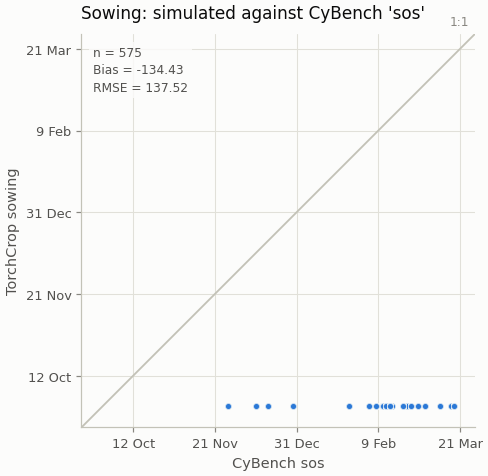

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_01_scatter_maturity(.png/.pdf)


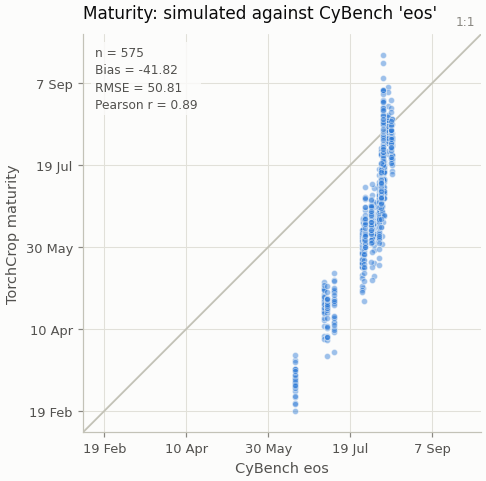

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_01_scatter_harvest(.png/.pdf)


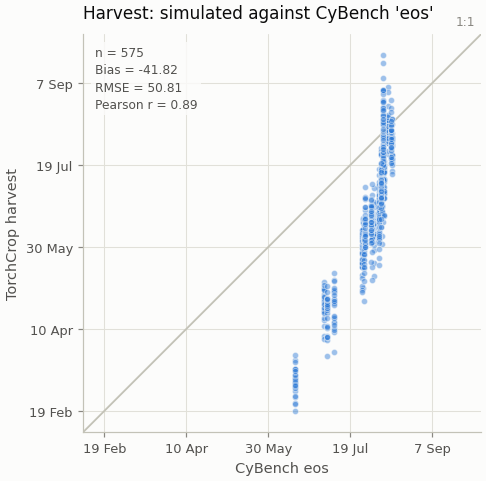

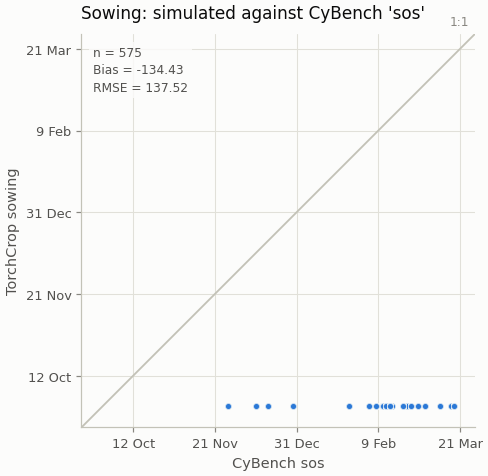

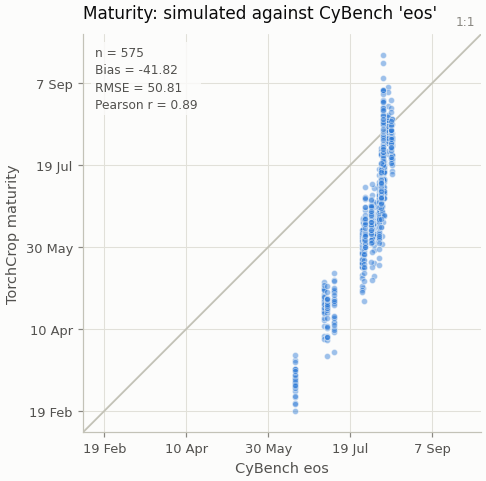

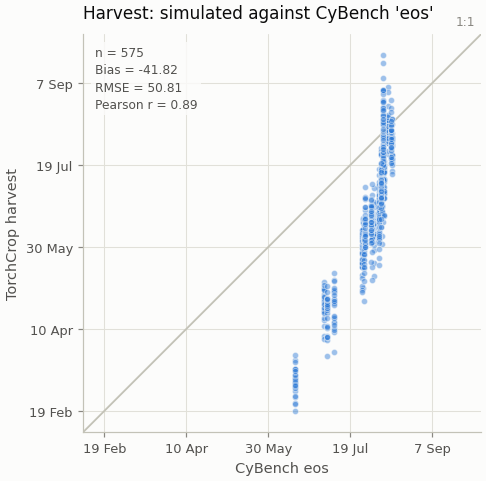

In [14]:
for stage in config.STAGES:
    fig = plots.scatter_one_to_one(
        paired, stage.obs_col, stage.sim_col, circular=True,
        stats=pooled[stage.label],
        metric_keys=("n", "bias", "rmse", "pearson_r"),
        title=f"{stage.label}: simulated against CyBench '{stage.obs_col}'",
        xlabel=f"CyBench {stage.obs_col}",
        ylabel=f"TorchCrop {stage.label.lower()}",
    )
    plots.save(fig, f"phenology_01_scatter_{stage.key}")
    display(fig)

### 8.2 Per country, for the maturity pairing

Only maturity gets the small-multiple treatment: it is the one pairing where
both sides mean the same thing, so it is the one where a per-country panel says
something about the model.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_02_maturity_small_multiples(.png/.pdf)


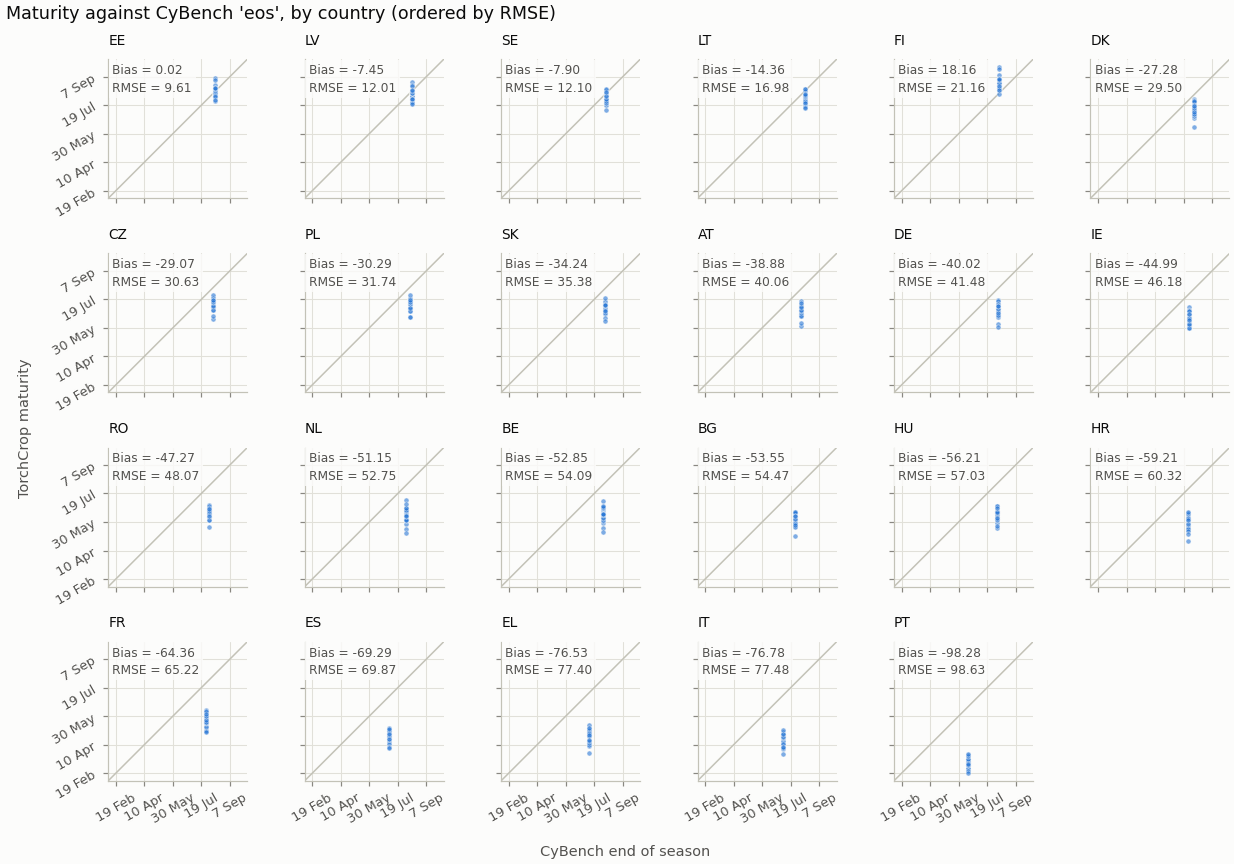

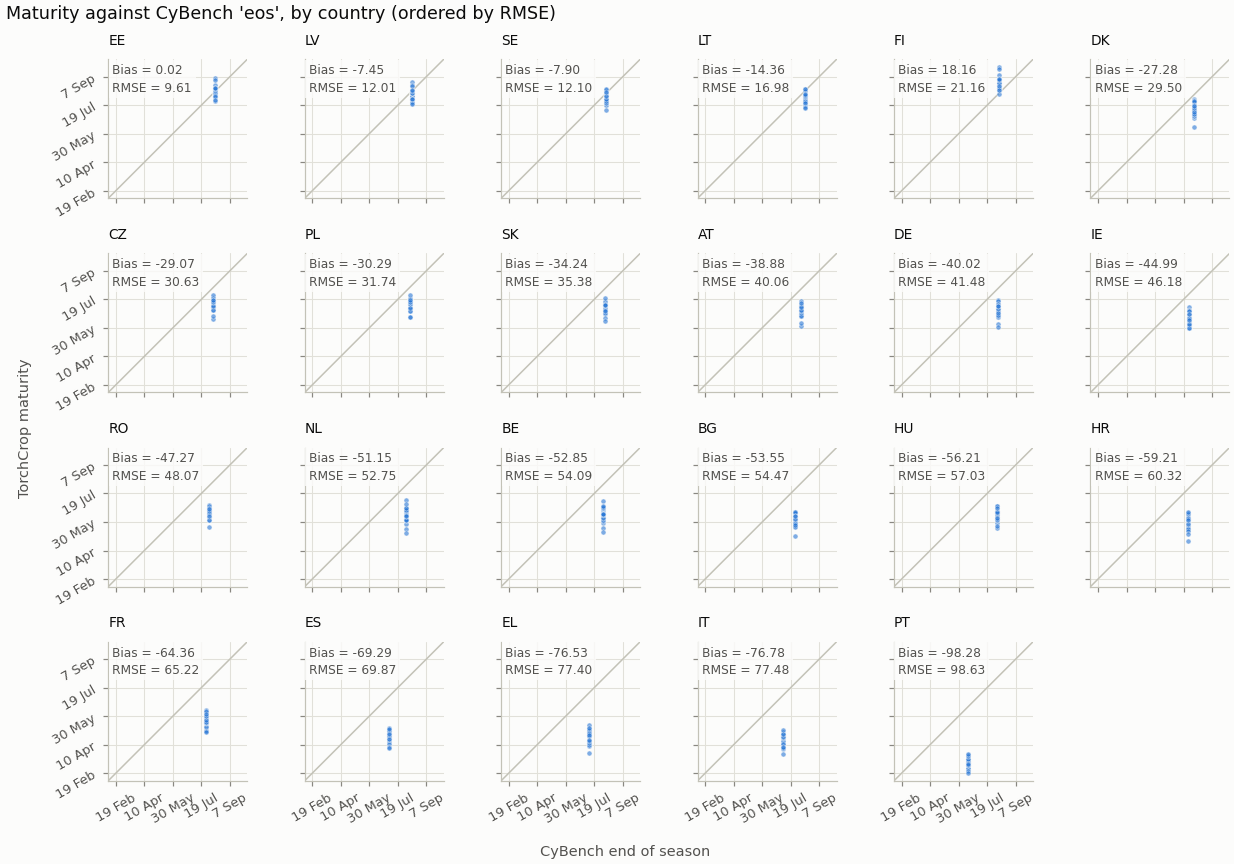

In [15]:
fig = plots.scatter_small_multiples(
    paired, "eos", "maturity_doy", metrics=stage_metrics["maturity"],
    order=[c for c in maturity_ranked.index if c != "ALL"],
    circular=True, annotate=("bias", "rmse"),
    title="Maturity against CyBench 'eos', by country (ordered by RMSE)",
    xlabel="CyBench end of season",
    ylabel="TorchCrop maturity",
)
plots.save(fig, "phenology_02_maturity_small_multiples")
fig

### 8.3 Country-wise bias, one figure per stage

Positive (warm) means the model is **late**.

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_03_bias_sowing(.png/.pdf)


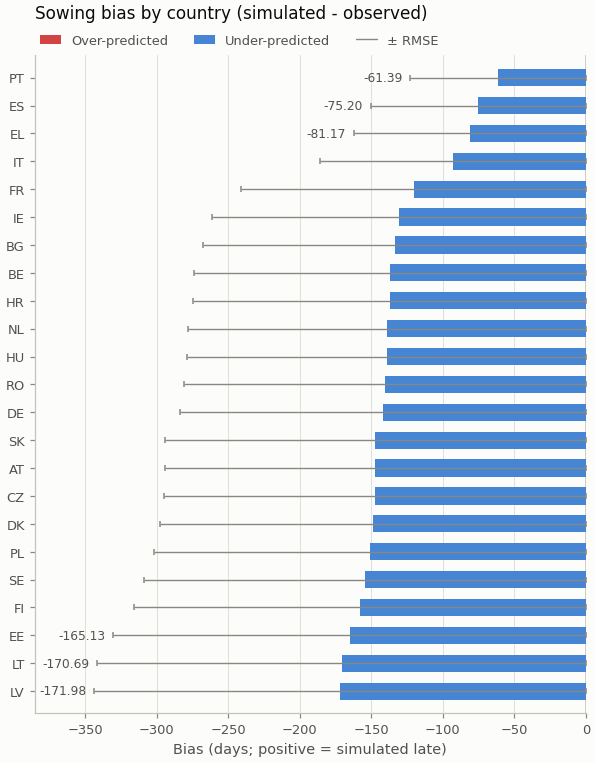

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_03_bias_maturity(.png/.pdf)


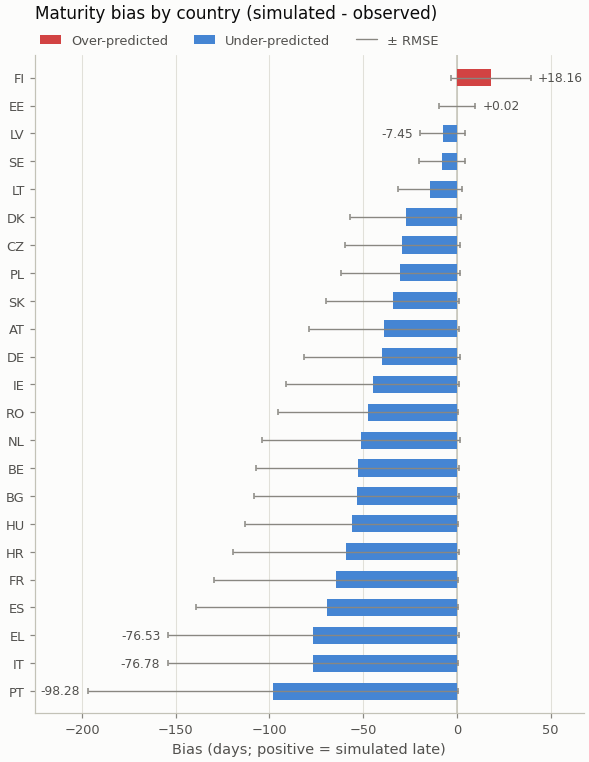

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_03_bias_harvest(.png/.pdf)


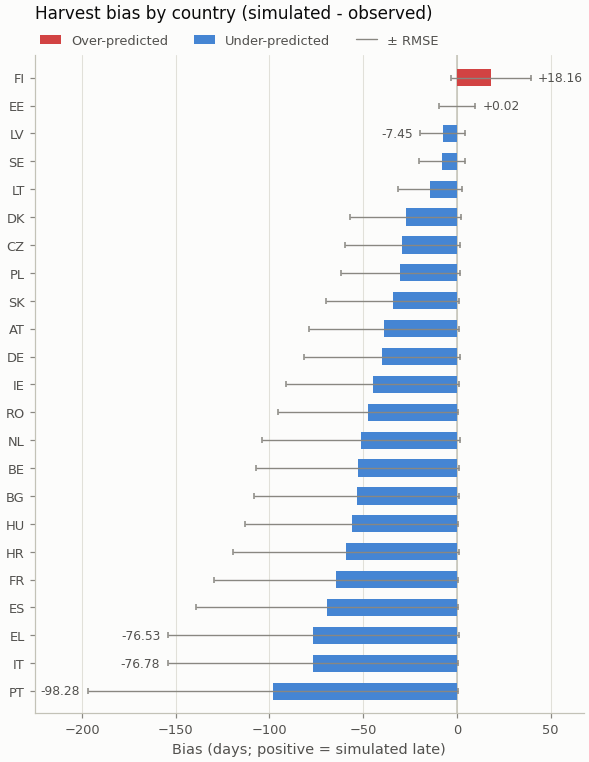

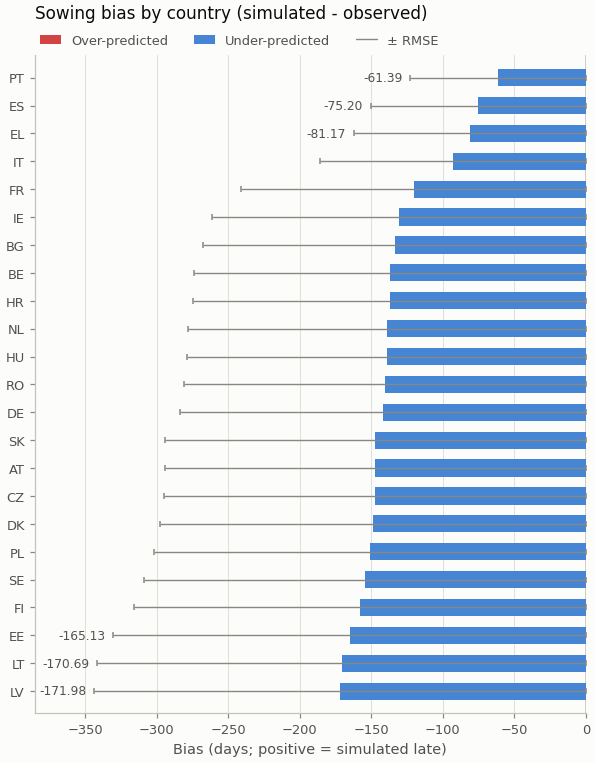

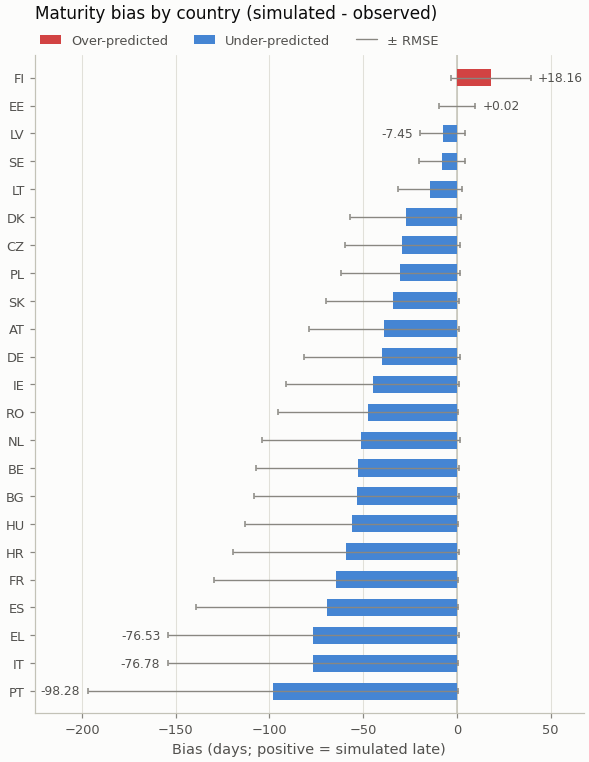

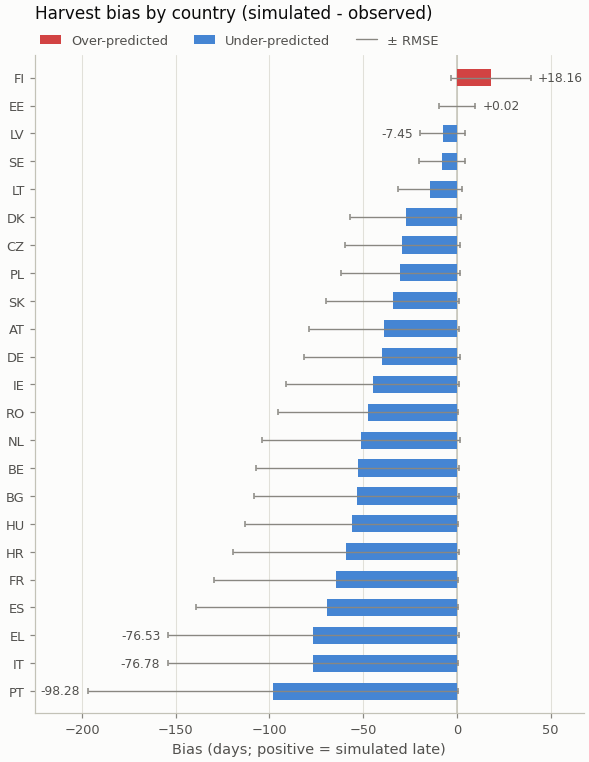

In [16]:
for stage in config.STAGES:
    fig = plots.bias_bars(
        metrics.rank_countries(stage_metrics[stage.key], by="bias"),
        value_col="bias", error_col="rmse",
        title=f"{stage.label} bias by country (simulated - observed)",
        xlabel="Bias (days; positive = simulated late)",
    )
    plots.save(fig, f"phenology_03_bias_{stage.key}")
    display(fig)

### 8.4 Maps

INFO utils.regions: 946 admin polygons across 23 countries


INFO utils.regions: dissolved to 23 national footprints


INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_04_map_bias_sowing(.png/.pdf)


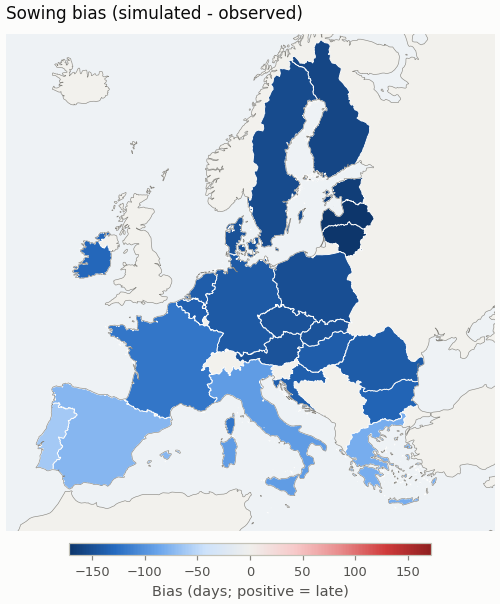

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_04_map_bias_maturity(.png/.pdf)


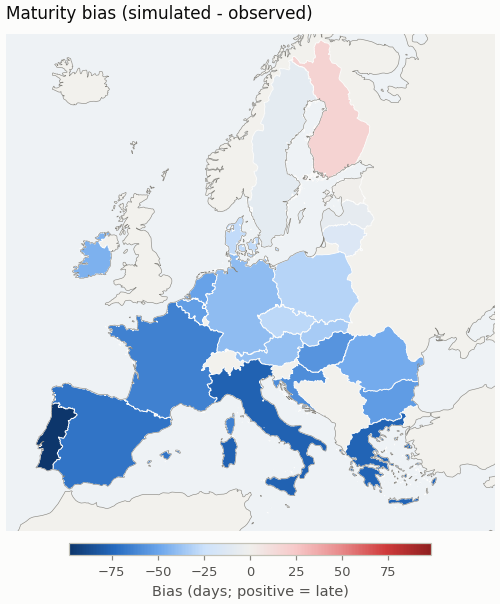

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_04_map_bias_harvest(.png/.pdf)


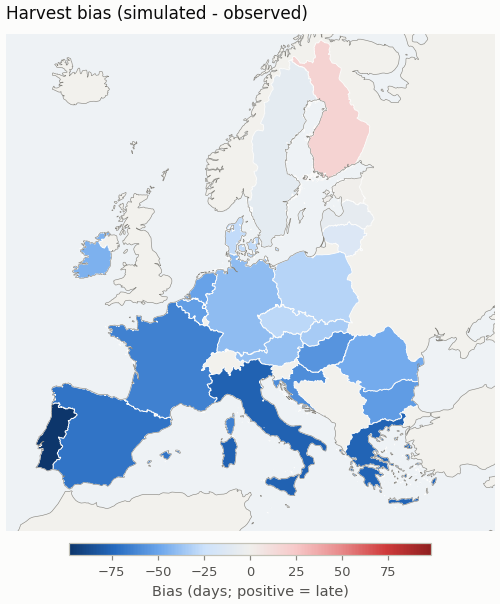

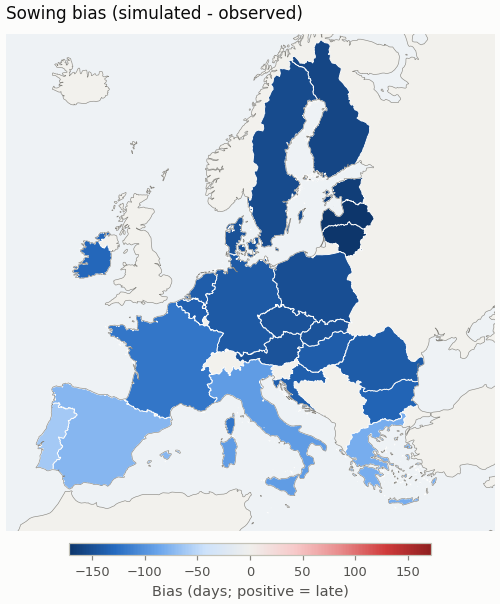

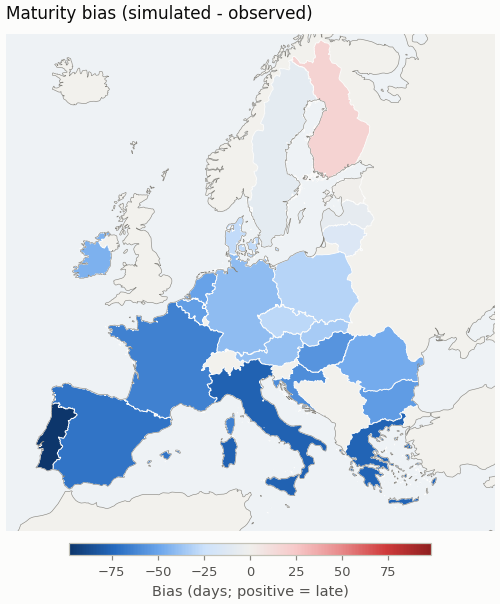

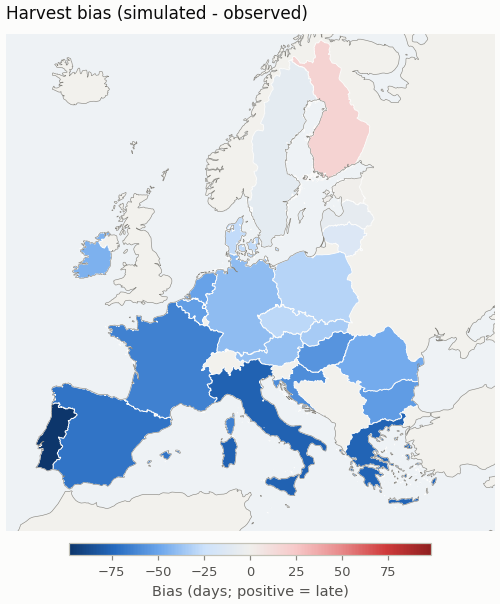

In [17]:
polygons = regions.load_country_polygons(COUNTRIES)

for stage in config.STAGES:
    fig = plots.country_choropleth(
        polygons, stage_metrics[stage.key]["bias"],
        title=f"{stage.label} bias (simulated - observed)",
        cbar_label="Bias (days; positive = late)", diverging=True,
    )
    plots.save(fig, f"phenology_04_map_bias_{stage.key}")
    display(fig)

INFO utils.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures/phenology_05_map_season_length(.png/.pdf)


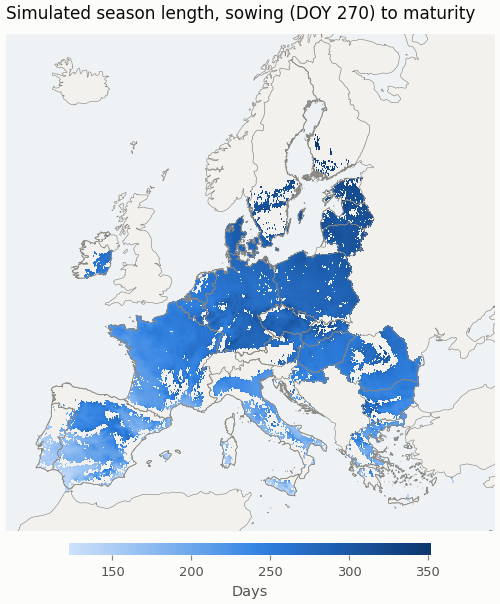

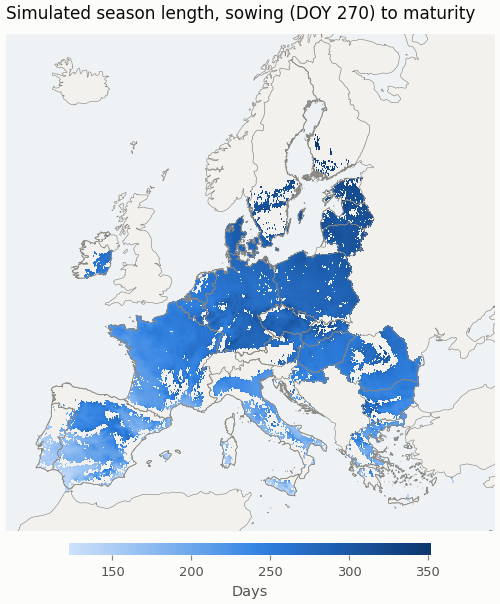

In [18]:
cell_maturity = (
    scoped.groupby(["SimplaceID", "lon", "lat"], as_index=False)
    .agg(days_to_maturity=("days_to_maturity", "mean"))
)

fig = plots.cell_map(
    cell_maturity, "days_to_maturity",
    title=f"Simulated season length, sowing (DOY {config.SIM_SOWING_DOY}) to maturity",
    cbar_label="Days", overlay=polygons,
)
plots.save(fig, "phenology_05_map_season_length")
fig

## 9. Summary

In [19]:
paired.to_csv(config.TABLE_DIR / "phenology_paired_country_year.csv",
              index=False, float_format="%.4f")
pooled_table.to_csv(config.TABLE_DIR / "phenology_metrics_pooled.csv",
                    float_format="%.3f")
print(f"tables written to {config.TABLE_DIR}")
print(f"figures written to {config.FIGURE_DIR}")

pooled_table[["n", "observed date", "simulated date", "bias", "mae", "rmse",
              "pearson_r"]].round(1)

tables written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/tables
figures written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/evaluation/outputs/figures


,n,observed date,simulated date,bias,mae,rmse,pearson_r
Sowing,575.0,9 Feb,27 Sep,-134.4,134.4,137.5,NaN
Maturity,575.0,30 Jul,19 Jun,-41.8,44.0,50.8,0.9
Harvest,575.0,30 Jul,19 Jun,-41.8,44.0,50.8,0.9


### What the numbers mean, and what they do not

* **Maturity is the only result to quote.** Both sides mean the same thing
  there, and the correlation across countries is real: the model orders the
  countries' seasons correctly even where it places them wrongly in absolute
  terms.
* **The maturity bias is not purely a model error.** CyBench `eos` is an end of
  season, which falls at or after harvest; simulated maturity is `DVS = 2`. Part
  of the gap is the maturity-to-harvest interval that LINTUL-5 does not model.
* **Sowing measures the DOY 270 assumption, not the model.** For the autumn-`sos`
  countries the bias is a real statement about that constant. For the
  green-up-`sos` countries it is a statement about the CyBench convention and
  should not be read as skill.
* **Harvest carries no information beyond maturity** while
  `config.HARVEST_LAG_DAYS` is 0.
* **The reference is climatological.** With no year dimension on `sos`/`eos`,
  none of these metrics test whether the model tracks a warm or a cold season —
  only whether it places the average season correctly.

Found 2 unique species: ['Triticum Triticum aestivum', 'Zea Zea mays']


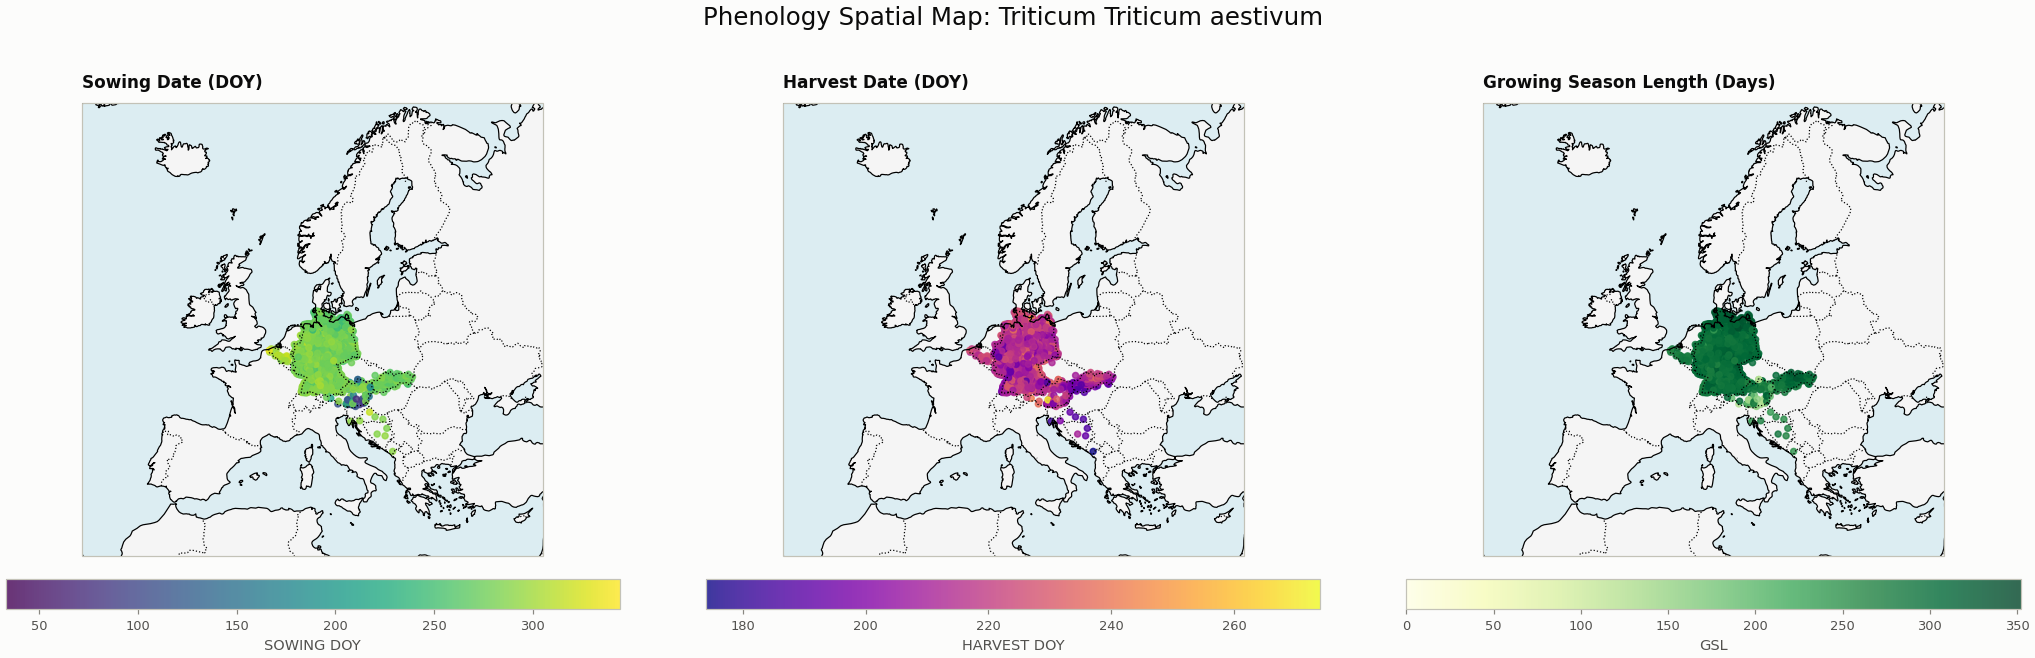

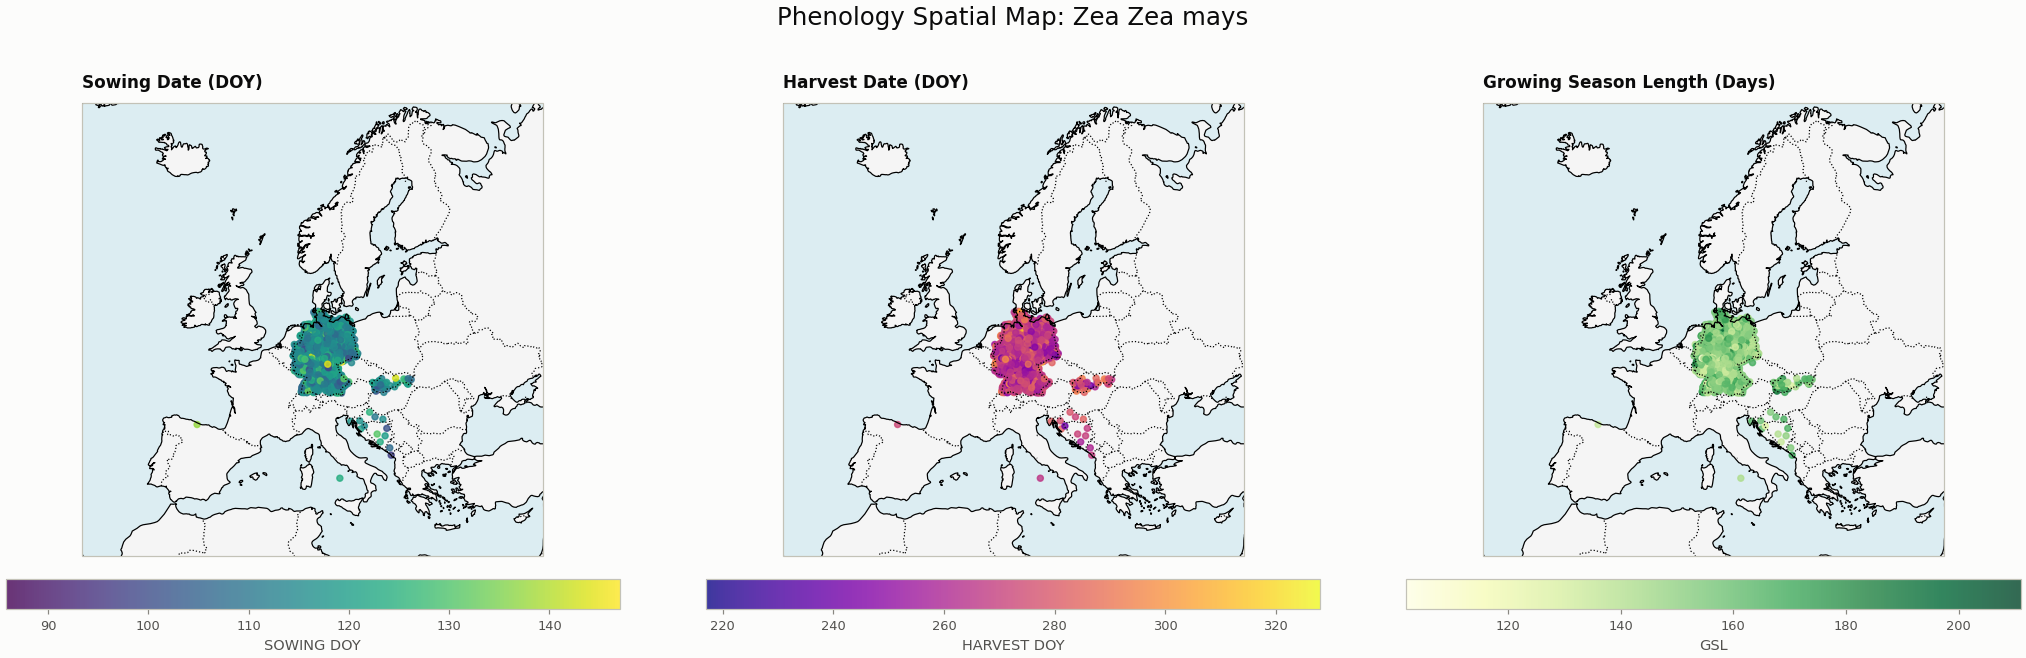

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Load Data
data_dir = "/data01/FDS/muduchuru/Data/Agri/PEP725"
files = [
    os.path.join(data_dir, "pep725_20260807_0.csv"),
    os.path.join(data_dir, "pep725_20260807_400000.csv")
]

dfs = []
for f in files:
    if os.path.exists(f):
        # PEP725 files use ';' separator[cite: 1]
        df = pd.read_csv(f, sep=';', low_memory=False)
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Drop completely duplicated rows across the dataset
data = data.drop_duplicates()

# 2. Identify Unique Species (Dropping NaN values and duplicates)
if 'species' in data.columns:
    data['full_species'] = data['genus'].fillna('') + ' ' + data['species'].fillna('')
    data['full_species'] = data['full_species'].str.strip()
else:
    data['full_species'] = data['genus']

# Drop NaN / empty strings and extract unique species
unique_species = (
    data['full_species']
    .replace('', np.nan)
    .dropna()
    .drop_duplicates()
    .tolist()
)

print(f"Found {len(unique_species)} unique species: {unique_species}")

# 3. Projection and Map Setup
proj = ccrs.LambertConformal(central_longitude=15, central_latitude=50)
data_crs = ccrs.PlateCarree()

# 4. Loop Over Each Unique Species
for species_name in unique_species:
    # Filter dataset for current species
    species_data = data[data['full_species'] == species_name]
    
    # Filter Phase IDs for Sowing (0) and Harvest (100) and drop NaNs in key columns[cite: 1]
    sowing_df = (
        species_data[species_data['phase_id'] == 0]
        .dropna(subset=['s_id', 'gss_id', 'year', 'day', 'lon', 'lat'])
        .drop_duplicates(subset=['s_id', 'gss_id', 'year'])
        .rename(columns={'day': 'sowing_doy'})
    )
    
    harvest_df = (
        species_data[species_data['phase_id'] == 100]
        .dropna(subset=['s_id', 'gss_id', 'year', 'day'])
        .drop_duplicates(subset=['s_id', 'gss_id', 'year'])
        .rename(columns={'day': 'harvest_doy'})
    )
    
    if sowing_df.empty or harvest_df.empty:
        print(f"Skipping '{species_name}': Insufficient sowing or harvest data.")
        continue

    # Merge by station, plant ID, and year[cite: 1]
    merged = pd.merge(
        sowing_df[['s_id', 'gss_id', 'year', 'lon', 'lat', 'sowing_doy']],
        harvest_df[['s_id', 'gss_id', 'year', 'harvest_doy']],
        on=['s_id', 'gss_id', 'year']
    )

    if merged.empty:
        print(f"Skipping '{species_name}': No overlapping station-year records.")
        continue

    # Calculate GSL (in days)
    merged['gsl'] = np.where(
        merged['harvest_doy'] >= merged['sowing_doy'],
        merged['harvest_doy'] - merged['sowing_doy'],
        (365 - merged['sowing_doy']) + merged['harvest_doy']
    )

    # Average by station location and drop any remaining NaNs in calculations
    station_summary = (
        merged.groupby(['s_id', 'lon', 'lat'])
        .agg({'sowing_doy': 'mean', 'harvest_doy': 'mean', 'gsl': 'mean'})
        .reset_index()
        .dropna(subset=['sowing_doy', 'harvest_doy', 'gsl'])
    )

    # Filter spatial bounds for Europe
    station_summary = station_summary[
        (station_summary['lon'] >= -25) & (station_summary['lon'] <= 45) & 
        (station_summary['lat'] >= 30) & (station_summary['lat'] <= 72)
    ]

    if station_summary.empty:
        print(f"Skipping '{species_name}': No valid station coordinates within bounds.")
        continue

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'projection': proj})
    variables = ['sowing_doy', 'harvest_doy', 'gsl']
    titles = ['Sowing Date (DOY)', 'Harvest Date (DOY)', 'Growing Season Length (Days)']
    cmaps = ['viridis', 'plasma', 'YlGn']

    for ax, var, title, cmap in zip(axes, variables, titles, cmaps):
        ax.set_extent([-15, 35, 33, 70], crs=data_crs)
        ax.add_feature(cfeature.LAND, facecolor='whitesmoke')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.4)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='black')
        
        sc = ax.scatter(
            station_summary['lon'],
            station_summary['lat'],
            c=station_summary[var],
            cmap=cmap,
            s=15,
            alpha=0.8,
            transform=data_crs
        )
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04, shrink=0.8)
        cbar.set_label(var.upper().replace('_', ' '))

    plt.suptitle(f'Phenology Spatial Map: {species_name}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [26]:
import xarray as xr
# file = '/data01/FDS/muduchuru/Data/Agri/GGCMI/ggcmi-crop-calendar-phase3_201soc_wwh_noirr.nc'
file = '/data01/FDS/muduchuru/Data/Agri/GGCMI/ggcmi-crop-calendar_gfdl-esm4_histsoc_wwh-noirr_annual_1991_2014.nc'
ds = xr.open_dataset(file, decode_times=False)

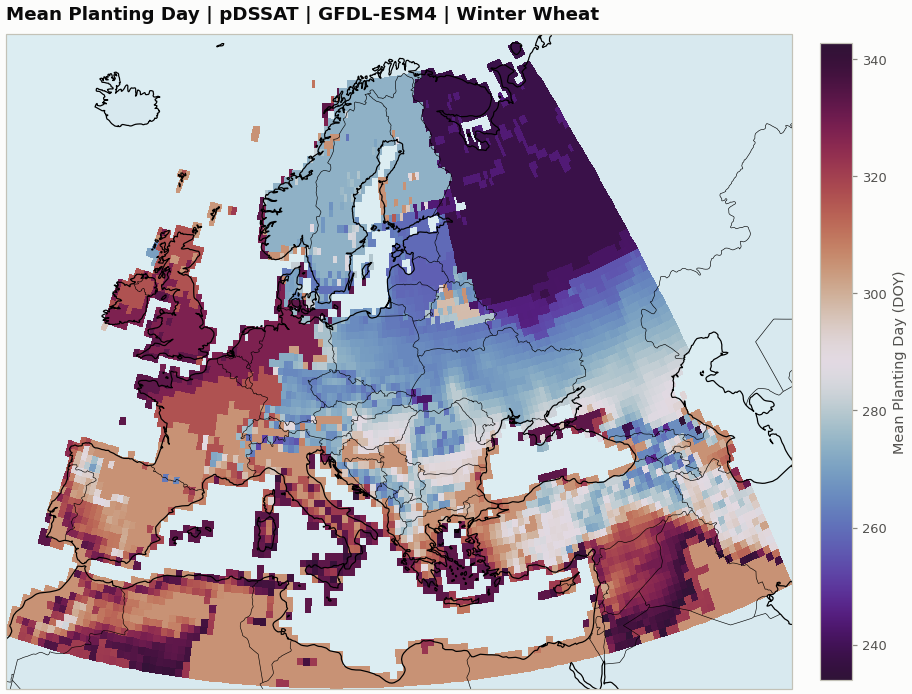

In [31]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file = '/data01/FDS/muduchuru/Data/Agri/GGCMI/ggcmi-crop-calendar_gfdl-esm4_histsoc_wwh-noirr_annual_1991_2014.nc'
ds = xr.open_dataset(file, decode_times=False)

# 1. Compute Mean Planting Day across all years
planting = ds["planting_day-mavg"].mean(dim="time")

# 2. Sort coordinates and crop to European region
planting = planting.sortby("lon").sortby("lat", ascending=False)
planting_eu = planting.sel(
    lat=slice(70, 30),
    lon=slice(-10, 50)
)

# 3. Define Cartopy Projection (Lambert Azimuthal Equal Area for Europe)
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=15,
    central_latitude=52
)
data_crs = ccrs.PlateCarree()

# 4. Plotting
fig, ax = plt.subplots(
    figsize=(9, 8),
    subplot_kw={"projection": proj}
)

im = ax.pcolormesh(
    planting_eu.lon,
    planting_eu.lat,
    planting_eu,
    transform=data_crs,
    cmap="twilight_shifted",
    shading="auto"
)

# Spatial Extent and Map Features
ax.set_extent([-10, 50, 30, 70], crs=data_crs)
ax.coastlines(resolution="50m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.4)

# Colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    shrink=0.75,
    pad=0.03
)
cbar.set_label("Mean Planting Day (DOY)")

# Title
ax.set_title(
    "Mean Planting Day | pDSSAT | GFDL-ESM4 | Winter Wheat",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()